**Problem 1 (100 pontos)**

Consider the system presented in Example 4.

(a) Construct a function that simulates this system, taking as inputs $N$ (number of events), $s$ (number of servers), $ρ$(system load), and $τ$ (average departure time).

In [7]:
import numpy as np

# seed
rng = np.random.default_rng(123)

# simulation
def simulate_loss_system(N: int, s: int, rho: float, tau: float, rng=None) -> float:
    if rng is None:
        rng = np.random.default_rng()

    lam = rho / tau  # arrivals per second

    t = 0.0
    t_next_arrival = rng.exponential(1.0 / lam)
    departure_times = []  # absolute times

    total_arrivals = 0
    blocked = 0

    while total_arrivals < N:
        t_next_departure = min(departure_times) if departure_times else np.inf

        if t_next_arrival <= t_next_departure:
            # Arrival
            t = t_next_arrival
            total_arrivals += 1

            if len(departure_times) < s:
                # Accept: schedule departure
                service_time = rng.exponential(tau)
                departure_times.append(t + service_time)
            else:
                # Block
                blocked += 1

            # schedule next arrival
            t_next_arrival = t + rng.exponential(1.0 / lam)
        else:
            # Departure
            t = t_next_departure
            departure_times.remove(t_next_departure)

    return blocked / total_arrivals


(b) Using the constructed function, plot a graph showing blocking probability curves as a function of load (ranging from 0.05 to 1 erlang, with steps of 0.05). 

Consider: 

$N = 200,000$, 

$τ = 10 seconds$, 

$s ∈ [1, 2]$. 

This graph will present two curves, one for each value of $s$.

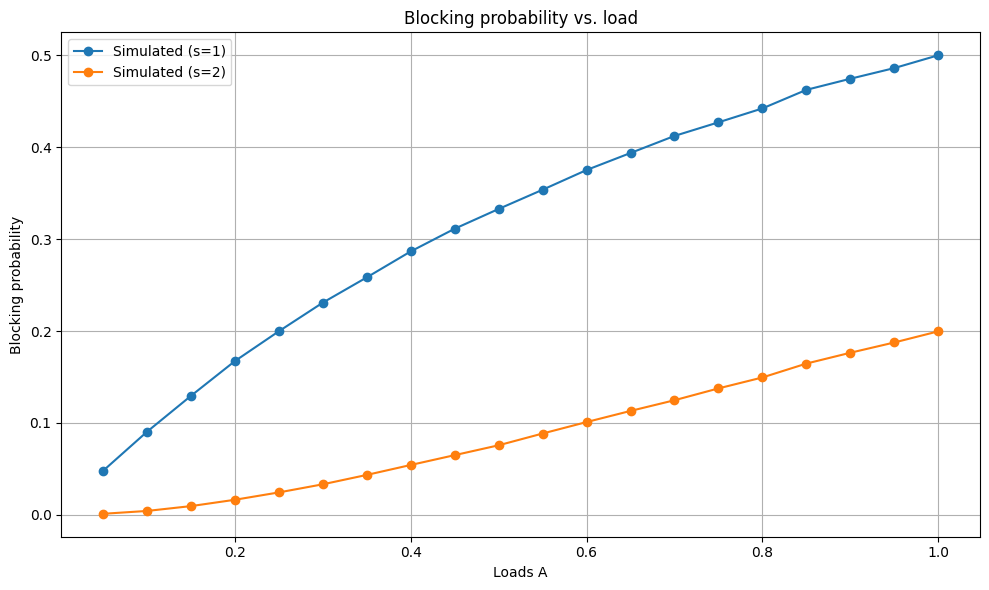

In [8]:
import matplotlib.pyplot as plt

# Parameters
N = 200_000
tau = 10.0  # seconds
loads = np.arange(0.05, 1.0 + 1e-9, 0.05)  # 0.05 ... 1.00 (step 0.05)
s_values = [1, 2]

sim_results = {1: [], 2: []}
for s in s_values:
    for A in loads:
        sim_results[s].append(simulate_loss_system(N=N, s=s, rho=A, tau=tau))

plt.figure(figsize=(10,6))
for s in s_values:
    plt.plot(loads, sim_results[s], marker='o', label=f"Simulated (s={s})")
plt.title("Blocking probability vs. load")
plt.xlabel("Loads A")
plt.ylabel("Blocking probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


(c) Compare the results obtained in (b) with the theoretical results obtained using the Erlang-B formula, plotting the theoretical and simulated results on the same graph.

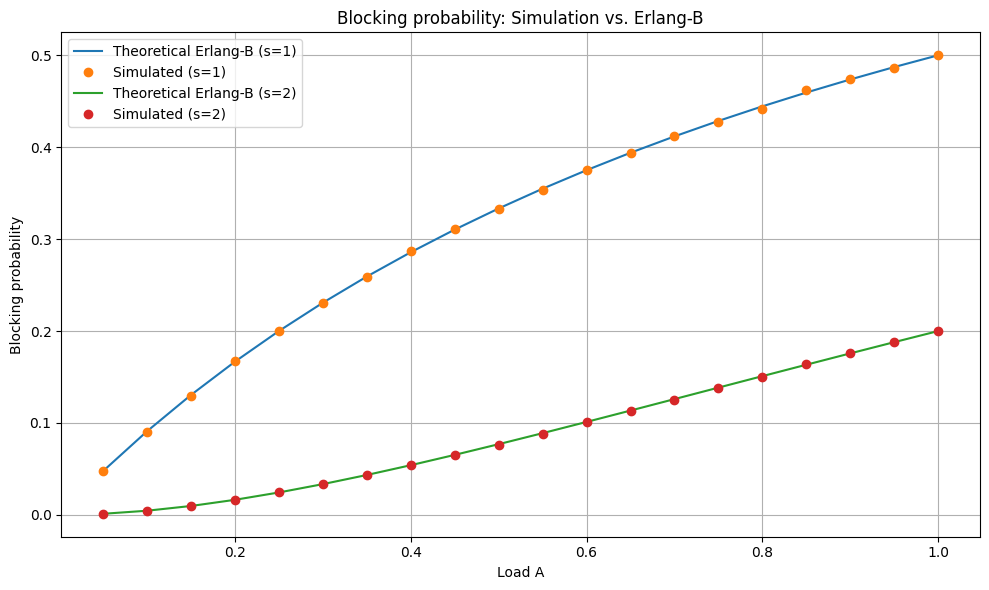

In [9]:
import math
import matplotlib.pyplot as plt

def erlangb(A, s):
    num = A**s / math.factorial(s)
    den = sum(A**i / math.factorial(i) for i in range(s+1))
    return num / den

theo_results = {
    1: [erlangb(A, 1) for A in loads],
    2: [erlangb(A, 2) for A in loads],
}

plt.figure(figsize=(10,6))
for s in [1, 2]:
    plt.plot(loads, theo_results[s], label=f"Theoretical Erlang-B (s={s})")
    plt.plot(loads, sim_results[s], marker='o', linestyle='None', label=f"Simulated (s={s})")

plt.title("Blocking probability: Simulation vs. Erlang-B")
plt.xlabel("Load A")
plt.ylabel("Blocking probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**Comments**

The simulated blocking probabilities align almost perfectly with Erlang-B across all loads, validating the simulator. 

As traffic increases, blocking rises, and a two-server system ($s=2$) consistently shows substantially lower loss than a single server ($s=1$)

**Joker Problem 2 (100 pontos)**

Consider Example 5, assuming: 

 - $n = 200,000$;

 - $S = 1$;

 - $L = 2$;

 - $λ = 0.8$; 

 - $τ = 1$. 


Modify the code so that it is possible to obtain:

(a) The average number of customers in the queue and the average number of customers in the system.

(b) The average queue time and the average system time.

(c) From these results, verify the validity of Little's Theorem:

In [10]:
import numpy as np
import math

rng = np.random.default_rng(7)


# Parameters
n   = 200_000   # number of arrival attempts (events)
S   = 1         # number of servers
L   = 2         # queue places
lbd = 0.8       # arrivals per minute
tau = 1.0       # mean service time (minutes)
mu  = 1.0 / tau # services per minute

# State and statistics

nb = 0                 # queued (admitted-to-queue) call id counter
tp = 0.0               # current simulation time
b  = 0                 # blocked calls counter

# Servers: store absolute release times (inf = idle)
T = np.inf * np.ones(S)

# Queue: L x 2 – [id, service_duration], inf means empty slot
Q = np.inf * np.ones((L, 2))
Qas = 0                 # current queue size

# For queued statistics: Qa[id, 1] = arrival time, Qa[id, 2] = service start
Qa = np.zeros((n, 3))   # will slice to used part later

# Time-average integrals for Lq and L
area_Lq = 0.0
area_L  = 0.0
last_t  = 0.0

def num_busy_servers():
    return np.isfinite(T).sum()

def accumulate_areas(new_t):
    global area_Lq, area_L, last_t, Qas, T
    dt = new_t - last_t
    if dt > 0:
        Lq_now = Qas
        L_now  = Qas + num_busy_servers()
        area_Lq += Lq_now * dt
        area_L  += L_now  * dt
        last_t = new_t

# Per-customer time stats for served customers
sum_Wq = 0.0
sum_W  = 0.0
served = 0

# Helper to process a departure event on server 'sv_idx'
def process_departure(sv_idx, current_time):
    global T, Q, Qas, Qa, served, sum_Wq, sum_W
    # One service completes at 'current_time'
    if Qas >= 1:
        # Next from queue enters service immediately
        start_time = current_time
        arr_id  = int(Q[0, 0])
        srv_dur = Q[0, 1]
        # Update per-customer stats
        arrival_time = Qa[arr_id, 1]
        Qa[arr_id, 2] = start_time
        Wq = start_time - arrival_time
        W  = Wq + srv_dur
        sum_Wq += Wq
        sum_W  += W
        served += 1
        # Occupy server until new release
        T[sv_idx] = current_time + srv_dur
        # Pop queue head (shift)
        Qas -= 1
        if L > 1:
            Q = np.roll(Q, -1, axis=0)
            Q[L-1, :] = np.inf
        else:
            Q[0, :] = np.inf
    else:
        # No one waiting; server becomes idle
        T[sv_idx] = np.inf

# simulation
for i in range(n):
    # Sample interarrival and service times
    tc = -1/lbd*np.log(1.0-np.random.random_sample()) # time to next arrival
    ts = -1/mu*np.log(1.0-np.random.random_sample()) # service duration of this arrival

    t_next_arrival = tp + tc

    # Advance time via departures up to next arrival
    while True:
        tmin = np.min(T)
        if tmin == np.inf or tmin >= t_next_arrival:
            # No departure before next arrival: jump to arrival
            accumulate_areas(t_next_arrival)
            tp = t_next_arrival
            break
        else:
            # A departure occurs before the next arrival
            sv_idx = int(np.argmin(T))
            accumulate_areas(tmin)
            tp = tmin
            process_departure(sv_idx, tp)

    # Arrival at time tp: try to seize server, else queue, else block
    idle = np.where(np.isinf(T))[0]
    if idle.size >= 1:
        # Directly served: Wq=0, W=service time
        sv_idx = idle[0]
        T[sv_idx] = tp + ts
        sum_Wq += 0.0
        sum_W  += ts
        served += 1
    else:
        # No server: try queue
        if L > 0 and Qas < L:
            Q[Qas, 0] = nb
            Q[Qas, 1] = ts
            Qa[nb, 0] = nb
            Qa[nb, 1] = tp  # arrival time for this queued job
            Qas += 1
            nb  += 1
        else:
            b += 1  # blocked

# Drain the system (finish all services)
while True:
    tmin = np.min(T)
    if tmin == np.inf:
        break
    sv_idx = int(np.argmin(T))
    accumulate_areas(tmin)
    tp = tmin
    process_departure(sv_idx, tp)

# Final time (simulation horizon)
tsim = tp

# Slice Qa just to used ids
Qa = Qa[:nb, :]

# Outputs
Pb = b / n
Lq_bar = area_Lq / tsim
L_bar  = area_L  / tsim

Wq_bar = sum_Wq / served if served > 0 else math.nan
W_bar  = sum_W  / served if served > 0 else math.nan

lam_eff = served / tsim   # throughput

print(f"Blocked fraction Pb = {Pb:.4f}")
print(f"Average in queue   Lq = {Lq_bar:.4f}")
print(f"Average in system   L = {L_bar:.4f}")
print(f"Average wait (queue) Wq = {Wq_bar:.4f} min")
print(f"Average time in system  W = {W_bar:.4f} min")
print(f"Effective rate lambda_eff = {lam_eff:.4f} per min")

# Little's Law checks
"""
Little's Law
For a stable system (arrivals and departures in steady state), the average number of items in the system is:
𝐿 = 𝜆 𝑊 L=λW
Where:
L: average number of customers/items in the system (queue + service) 
λ: average effective arrival rate (items/time) that actually enter the system, 
W: average dwell time in the system (waiting + service).
"""

lhs_Lq = Lq_bar
rhs_Lq = lam_eff * Wq_bar
lhs_L  = L_bar
rhs_L  = lam_eff * W_bar

print("\nLittle's Law checks (finite K uses lambda_eff):")
print(f" Lq  vs lambda_eff*Wq: {lhs_Lq:.4f}  vs  {rhs_Lq:.4f}")
print(f"  L  vs lambda_eff*W : {lhs_L :.4f}  vs  {rhs_L :.4f}")

Blocked fraction Pb = 0.1749
Average in queue   Lq = 0.5661
Average in system   L = 1.2270
Average wait (queue) Wq = 0.8566 min
Average time in system  W = 1.8564 min
Effective rate lambda_eff = 0.6609 per min

Little's Law checks (finite K uses lambda_eff):
 Lq  vs lambda_eff*Wq: 0.5661  vs  0.5661
  L  vs lambda_eff*W : 1.2270  vs  1.2270
